In [6]:
import pygame
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import animation
from collections import deque  ## multiple frame

print(torch.cuda.is_available())  # 應該為 True
print(torch.version.cuda)         # 應該列出 CUDA 版本
print(torch.backends.cudnn.version())  # cuDNN 版本

script_dir = os.path.join(os.getcwd(), 'space_ship_game_RL')
if script_dir not in sys.path:
    sys.path.append(script_dir)

from setting import *
from game import Game
from Env import SpaceShipEnv

class MLPDDQN(nn.Module):
    def __init__(self, input_dim, num_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_actions)
        )
    def forward(self, x):
        return self.net(x)

version = "v2.4.5"
episode = "1750"
ckpt_path = f"{version}/checkpoint_ep{episode}.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


env = SpaceShipEnv()
state_np = env.reset()                               # numpy.ndarray
input_dim  = state_np.shape[0]
num_actions = 4

model = MLPDDQN(input_dim, num_actions).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['policy_net'])
# model.load_state_dict(ckpt)
model.eval()

True
12.8
90701
Using device: cuda


MLPDDQN(
  (net): Sequential(
    (0): Linear(in_features=51, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [7]:
# Visualization of trained agent
env.render()
state = state_np
done = False
total_reward = 0
frames = []

while not done:
    state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
    with torch.no_grad():
        action = model(state_tensor).argmax(dim=1).item()
        
    # ---- 執行一步 ----
    next_state, reward, done, score = env.step(action)
    total_reward += reward
    state = next_state    
    
    # 把畫面抓下來（RGB）
    surface = pygame.display.get_surface()
    frame = np.transpose(pygame.surfarray.array3d(surface), (1, 0, 2))     # pygame 是 x,y → imageio 是 y,x
    frames.append(frame)

    pygame.event.pump() # 避免無回應

print(f"reward: {total_reward}, score: {score}")
print(len(frames))
env.close()

reward: 1099.6483999999987, score: 5280
8337


In [9]:
import imageio

video_path = f"video/{version}_ep{episode}_{score}.mp4"

imageio.mimsave(video_path, frames, fps=60, quality=9)
print(f"Saved gameplay video to: {video_path}")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (250, 300) to (256, 304) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved gameplay video to: video/v2.4.5_ep1750_5280.mp4


Loaded checkpoint from episode 1700, best_avg_score: 4072.04, epsilon=0.200


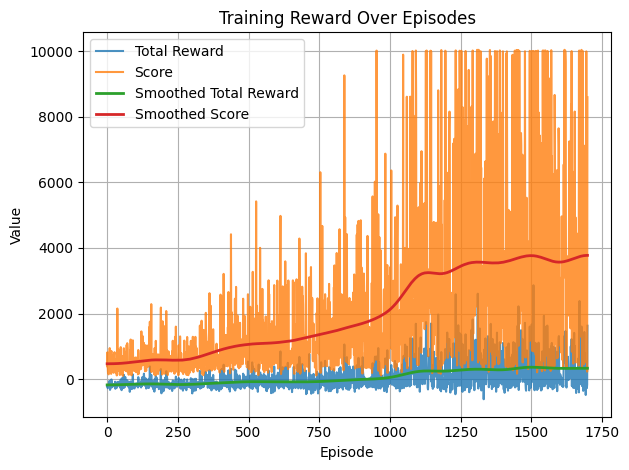

In [8]:
from scipy.ndimage import gaussian_filter1d

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    start_episode  = ckpt["episode"] + 1
    total_steps    = ckpt["total_steps"]
    best_avg_score = ckpt["best_avg_score"]
    best_avg_reward= ckpt["best_avg_reward"]
    epsilon = max(0.2, ckpt["epsilon"])                   # ★
    reward_history = ckpt['reward_history']
    score_history = ckpt['score_history']
    score_window  = deque(score_history[-100:],  maxlen=100)  # ★
    reward_window = deque(reward_history[-100:], maxlen=100)  # ★
    print(f"Loaded checkpoint from episode {start_episode}, best_avg_score: {best_avg_score:.2f}, epsilon={epsilon:.3f}")

reward_smooth = gaussian_filter1d(reward_history, sigma=50)
score_smooth = gaussian_filter1d(score_history, sigma=50)

# 畫圖
# plt.figure(figsize=(10, 5))
plt.plot(reward_history, label='Total Reward', alpha=0.8)
plt.plot(score_history, label='Score', alpha=0.8)
plt.plot(reward_smooth, label='Smoothed Total Reward', linewidth=2)
plt.plot(score_smooth, label='Smoothed Score', linewidth=2)

plt.legend(loc='upper left')
plt.xlabel("Episode")
plt.ylabel("Value")
plt.title("Training Reward Over Episodes")
plt.grid(True)
plt.tight_layout()
# plt.savefig("dqn_training_curve.png")